# IA Workshop - Regresión Logística
## Predicción de Aprobación de Exámenes

Este notebook implementa un modelo de regresión logística para predecir si un estudiante aprobará un examen basándose en las horas de estudio.

## Paso 1: Importar las Librerías Necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Para visualizaciones bonitas
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Todas las librerías importadas correctamente")

✓ Todas las librerías importadas correctamente


## EJEMPLO 1: Datos Ideales (Sin Variabilidad)

En este primer ejemplo, usamos datos "perfectos" donde hay una clara división entre aprobados y no aprobados.

### Paso 2: Crear un Dataset Ficticio (Escenario Ideal)

In [2]:
# Datos simulados: horas estudiadas y si pasaron o no el examen
horas_estudiadas_ideal = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
resultado_examen_ideal = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Crear DataFrame para visualizar mejor
df_ideal = pd.DataFrame({
    'Horas Estudiadas': horas_estudiadas_ideal,
    'Aprobado (1) / No Aprobado (0)': resultado_examen_ideal
})

print("DATOS IDEALES (SIN VARIABILIDAD)")
print("="*50)
print(df_ideal)
print("\nCaracterísticas:")
print("- División clara: Estudiantes con ≤4 horas no aprueban")
print("- División clara: Estudiantes con ≥5 horas aprueban")
print("- Sin excepciones ni sorpresas")

DATOS IDEALES (SIN VARIABILIDAD)
   Horas Estudiadas  Aprobado (1) / No Aprobado (0)
0                 1                               0
1                 2                               0
2                 3                               0
3                 4                               0
4                 5                               1
5                 6                               1
6                 7                               1
7                 8                               1
8                 9                               1
9                10                               1

Características:
- División clara: Estudiantes con ≤4 horas no aprueban
- División clara: Estudiantes con ≥5 horas aprueban
- Sin excepciones ni sorpresas


### Paso 3: Entrenar el Modelo con Datos Ideales

In [3]:
# Crear y entrenar el modelo de regresión logística
modelo_ideal = LogisticRegression()
modelo_ideal.fit(horas_estudiadas_ideal.reshape(-1, 1), resultado_examen_ideal)

print("✓ Modelo entrenado exitosamente")
print(f"\nCoeficientes del modelo (Escenario Ideal):")
print(f"  Intercepto (β₀): {modelo_ideal.intercept_[0]:.4f}")
print(f"  Coeficiente (β₁): {modelo_ideal.coef_[0][0]:.4f}")
print(f"\nInterpretación:")
print(f"  - Intercepto negativo: sin estudiar, probabilidad de aprobar es muy baja")
print(f"  - Coeficiente positivo: cada hora de estudio aumenta significativamente las chances")

✓ Modelo entrenado exitosamente

Coeficientes del modelo (Escenario Ideal):
  Intercepto (β₀): -5.3117
  Coeficiente (β₁): 1.1819

Interpretación:
  - Intercepto negativo: sin estudiar, probabilidad de aprobar es muy baja
  - Coeficiente positivo: cada hora de estudio aumenta significativamente las chances


### Paso 4: Hacer Predicciones - Generar Curva Sigmoide

In [4]:
# Predecir probabilidades para una gama de horas estudiadas
horas_rango = np.linspace(0, 12, 1000).reshape(-1, 1)
probabilidades_ideal = modelo_ideal.predict_proba(horas_rango)[:, 1]

# Predicciones binarias (0 o 1) con umbral de 0.5
predicciones_binarias = modelo_ideal.predict(horas_rango)

print("✓ Predicciones generadas para 1000 puntos")
print(f"\nRango de probabilidades:")
print(f"  Mínimo: {probabilidades_ideal.min():.4f}")
print(f"  Máximo: {probabilidades_ideal.max():.4f}")

✓ Predicciones generadas para 1000 puntos

Rango de probabilidades:
  Mínimo: 0.0049
  Máximo: 0.9999


### Paso 5: Visualizar los Resultados (Escenario Ideal)

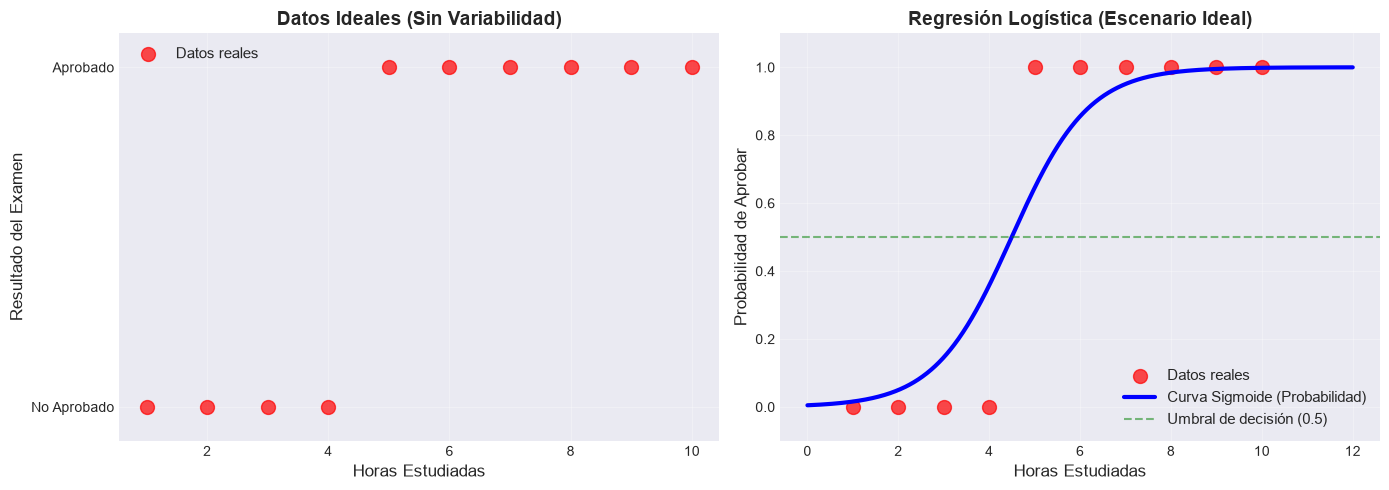


✓ Gráficos generados exitosamente


In [5]:
# Figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Solo los datos
ax1.scatter(horas_estudiadas_ideal, resultado_examen_ideal, color='red', s=100, alpha=0.7, label='Datos reales')
ax1.set_xlabel('Horas Estudiadas', fontsize=12)
ax1.set_ylabel('Resultado del Examen', fontsize=12)
ax1.set_title('Datos Ideales (Sin Variabilidad)', fontsize=14, fontweight='bold')
ax1.set_ylim(-0.1, 1.1)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['No Aprobado', 'Aprobado'])
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Datos + Curva de probabilidad
ax2.scatter(horas_estudiadas_ideal, resultado_examen_ideal, color='red', s=100, alpha=0.7, label='Datos reales')
ax2.plot(horas_rango, probabilidades_ideal, color='blue', linewidth=3, label='Curva Sigmoide (Probabilidad)')
ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Umbral de decisión (0.5)')
ax2.set_xlabel('Horas Estudiadas', fontsize=12)
ax2.set_ylabel('Probabilidad de Aprobar', fontsize=12)
ax2.set_title('Regresión Logística (Escenario Ideal)', fontsize=14, fontweight='bold')
ax2.set_ylim(-0.1, 1.1)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Gráficos generados exitosamente")

### Paso 6: Crear Tabla de Probabilidades (Escenario Ideal)

In [6]:
# Obtener probabilidades para las horas estudiadas originales
probabilidades_originales_ideal = modelo_ideal.predict_proba(horas_estudiadas_ideal.reshape(-1, 1))[:, 1]
predicciones_ideal = modelo_ideal.predict(horas_estudiadas_ideal.reshape(-1, 1))

# Crear DataFrame con resultados
datos_resultado_ideal = pd.DataFrame({
    'Horas Estudiadas': horas_estudiadas_ideal,
    'Resultado Real': resultado_examen_ideal,
    'Probabilidad Predicha': probabilidades_originales_ideal,
    'Predicción': predicciones_ideal
})

print("\nTABLA DE PROBABILIDADES (ESCENARIO IDEAL)")
print("="*70)
print(datos_resultado_ideal.to_string(index=False))

# Análisis de la tabla
print("\nANÁLISIS:")
print(f"- Accuracy (exactitud): {accuracy_score(resultado_examen_ideal, predicciones_ideal):.2%}")
print(f"- El modelo clasifica perfectamente en este escenario ideal")


TABLA DE PROBABILIDADES (ESCENARIO IDEAL)
 Horas Estudiadas  Resultado Real  Probabilidad Predicha  Predicción
                1               0               0.015833           0
                2               0               0.049842           0
                3               0               0.146062           0
                4               0               0.358041           0
                5               1               0.645215           1
                6               1               0.855700           1
                7               1               0.950826           1
                8               1               0.984387           1
                9               1               0.995159           1
               10               1               0.998510           1

ANÁLISIS:
- Accuracy (exactitud): 100.00%
- El modelo clasifica perfectamente en este escenario ideal


---

## EJEMPLO 2: Datos con Variabilidad Real

En el mundo real, los datos casi nunca son tan perfectos. Hay excepciones, anomalías y casos inesperados.

### Paso 1: Crear Datos con Variabilidad

In [7]:
# Nuevos datos con variabilidad: casos inesperados
horas_estudiadas_real = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1, 8, 5, 7, 9])
resultado_examen_real = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0])

# Crear DataFrame
df_real = pd.DataFrame({
    'Horas Estudiadas': horas_estudiadas_real,
    'Aprobado (1) / No Aprobado (0)': resultado_examen_real
})

print("DATOS CON VARIABILIDAD (MUNDO REAL)")
print("="*50)
print(df_real)
print("\nCasos Inesperados:")
print("  1. Estudiante con 1h → No aprobó (esperado)")
print("  2. Estudiante con 8h → No aprobó (¡inesperado!)")
print("  3. Estudiante con 5h → Aprobó (esperado)")
print("  4. Estudiante con 9h → No aprobó (¡muy inesperado!)")
print("\nPosibles razones de variabilidad:")
print("  - Examen más difícil de lo esperado")
print("  - Estudiante con mala técnica de estudio")
print("  - Problemas de salud o estrés")
print("  - Conocimientos previos")
print("  - Suerte en la selección de preguntas")

DATOS CON VARIABILIDAD (MUNDO REAL)
    Horas Estudiadas  Aprobado (1) / No Aprobado (0)
0                  1                               0
1                  2                               0
2                  3                               0
3                  4                               0
4                  5                               1
5                  6                               1
6                  7                               1
7                  8                               1
8                  9                               1
9                 10                               1
10                 1                               0
11                 8                               0
12                 5                               1
13                 7                               1
14                 9                               0

Casos Inesperados:
  1. Estudiante con 1h → No aprobó (esperado)
  2. Estudiante con 8h → No aprobó (¡inesperado!)


### Paso 2: Entrenar el Modelo con Datos Reales

In [8]:
# Crear y entrenar el modelo
modelo_real = LogisticRegression()
modelo_real.fit(horas_estudiadas_real.reshape(-1, 1), resultado_examen_real)

print("✓ Modelo entrenado con datos reales")
print(f"\nCoeficientes del modelo (Con Variabilidad):")
print(f"  Intercepto (β₀): {modelo_real.intercept_[0]:.4f}")
print(f"  Coeficiente (β₁): {modelo_real.coef_[0][0]:.4f}")
print(f"\nComparación con el modelo ideal:")
print(f"  Intercepto ideal: {modelo_ideal.intercept_[0]:.4f} → Con variabilidad: {modelo_real.intercept_[0]:.4f}")
print(f"  Coeficiente ideal: {modelo_ideal.coef_[0][0]:.4f} → Con variabilidad: {modelo_real.coef_[0][0]:.4f}")
print(f"\nInterpretación:")
print(f"  - El intercepto es más alto (menos pesimista con pocas horas)")
print(f"  - El coeficiente es más bajo (cada hora no garantiza tanto éxito)")

✓ Modelo entrenado con datos reales

Coeficientes del modelo (Con Variabilidad):
  Intercepto (β₀): -2.3728
  Coeficiente (β₁): 0.4446

Comparación con el modelo ideal:
  Intercepto ideal: -5.3117 → Con variabilidad: -2.3728
  Coeficiente ideal: 1.1819 → Con variabilidad: 0.4446

Interpretación:
  - El intercepto es más alto (menos pesimista con pocas horas)
  - El coeficiente es más bajo (cada hora no garantiza tanto éxito)


### Paso 3: Hacer Predicciones con Datos Reales

In [9]:
# Predecir probabilidades
probabilidades_real = modelo_real.predict_proba(horas_rango)[:, 1]
predicciones_reales = modelo_real.predict(horas_rango)

print("✓ Predicciones generadas")
print(f"\nRango de probabilidades (con variabilidad):")
print(f"  Mínimo: {probabilidades_real.min():.4f}")
print(f"  Máximo: {probabilidades_real.max():.4f}")
print(f"\nComparación:")
print(f"  Ideal - Rango: [{probabilidades_ideal.min():.4f}, {probabilidades_ideal.max():.4f}]")
print(f"  Real  - Rango: [{probabilidades_real.min():.4f}, {probabilidades_real.max():.4f}]")
print(f"  → La variabilidad hace que el rango sea más estrecho")

✓ Predicciones generadas

Rango de probabilidades (con variabilidad):
  Mínimo: 0.0853
  Máximo: 0.9509

Comparación:
  Ideal - Rango: [0.0049, 0.9999]
  Real  - Rango: [0.0853, 0.9509]
  → La variabilidad hace que el rango sea más estrecho


### Paso 4: Visualizar Datos Reales vs Ideales

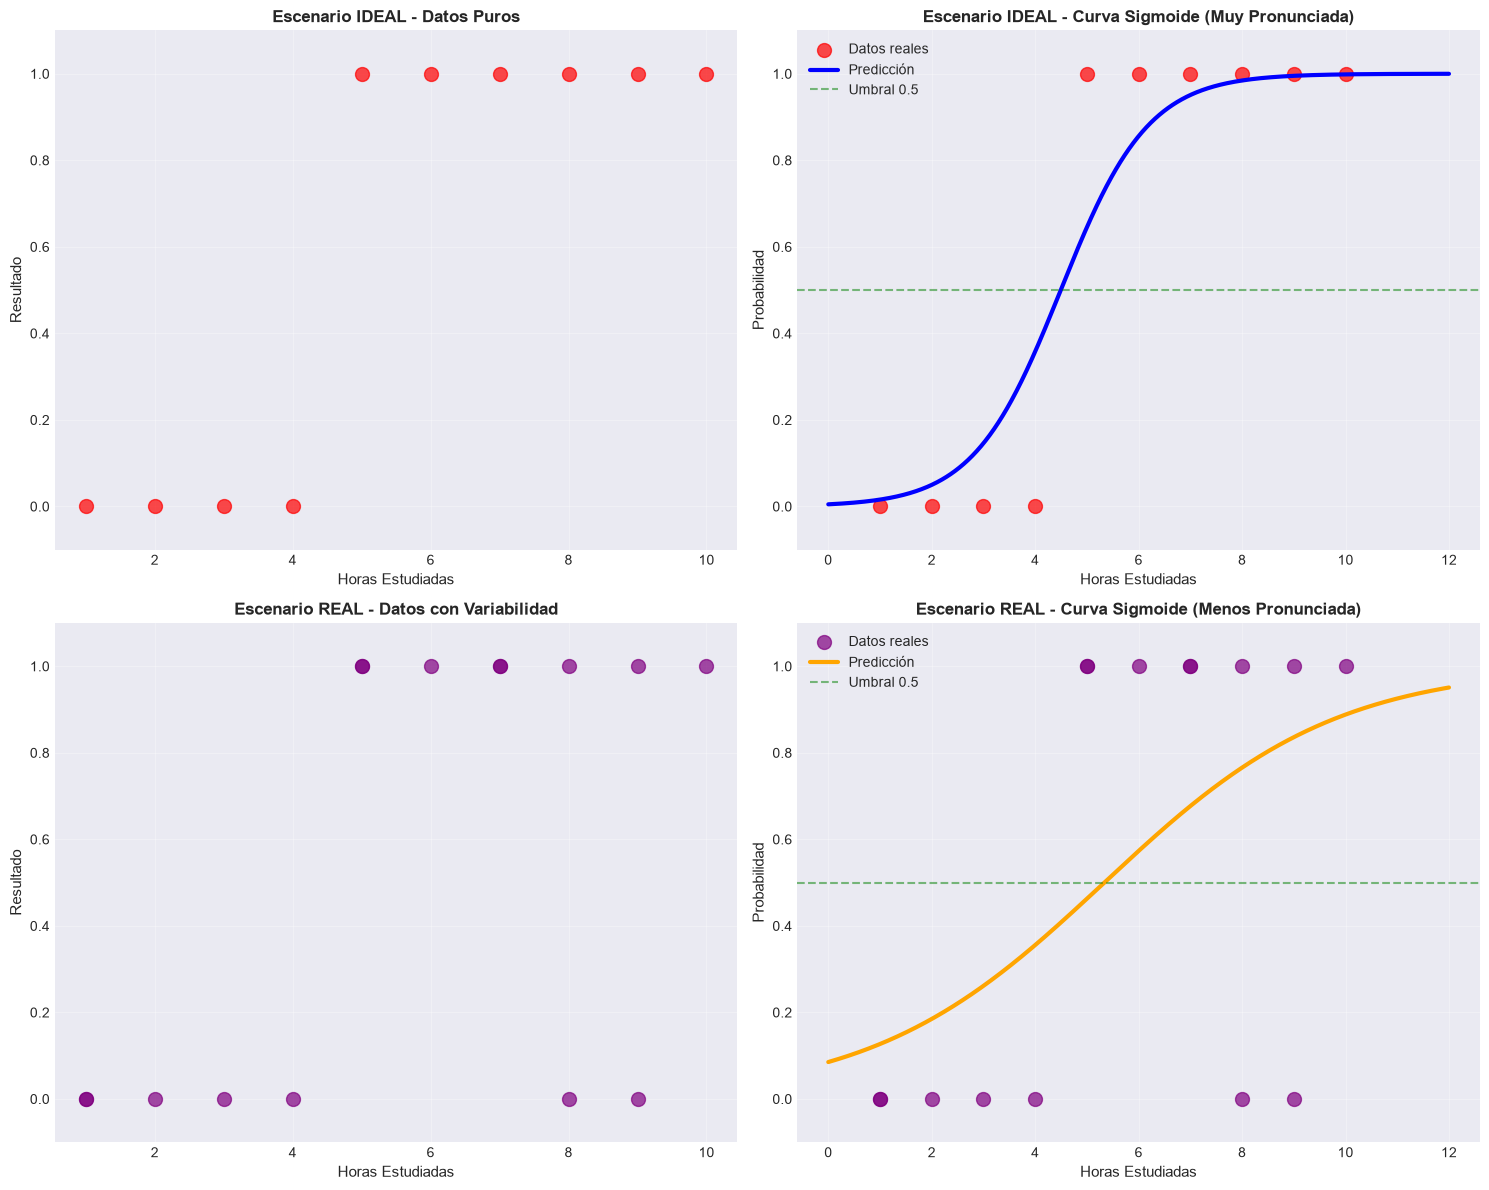

✓ Comparación visualizada


In [10]:
# Figura comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Fila 1: Escenario Ideal
ax = axes[0, 0]
ax.scatter(horas_estudiadas_ideal, resultado_examen_ideal, color='red', s=100, alpha=0.7)
ax.set_xlabel('Horas Estudiadas', fontsize=11)
ax.set_ylabel('Resultado', fontsize=11)
ax.set_title('Escenario IDEAL - Datos Puros', fontsize=12, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(horas_estudiadas_ideal, resultado_examen_ideal, color='red', s=100, alpha=0.7, label='Datos reales')
ax.plot(horas_rango, probabilidades_ideal, color='blue', linewidth=3, label='Predicción')
ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Umbral 0.5')
ax.set_xlabel('Horas Estudiadas', fontsize=11)
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Escenario IDEAL - Curva Sigmoide (Muy Pronunciada)', fontsize=12, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Fila 2: Escenario Real
ax = axes[1, 0]
ax.scatter(horas_estudiadas_real, resultado_examen_real, color='purple', s=100, alpha=0.7)
ax.set_xlabel('Horas Estudiadas', fontsize=11)
ax.set_ylabel('Resultado', fontsize=11)
ax.set_title('Escenario REAL - Datos con Variabilidad', fontsize=12, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(horas_estudiadas_real, resultado_examen_real, color='purple', s=100, alpha=0.7, label='Datos reales')
ax.plot(horas_rango, probabilidades_real, color='orange', linewidth=3, label='Predicción')
ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Umbral 0.5')
ax.set_xlabel('Horas Estudiadas', fontsize=11)
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Escenario REAL - Curva Sigmoide (Menos Pronunciada)', fontsize=12, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Comparación visualizada")

### Paso 5: Crear Tabla de Resultados (Datos Reales)

In [11]:
# Obtener probabilidades y predicciones
probabilidades_originales_real = modelo_real.predict_proba(horas_estudiadas_real.reshape(-1, 1))[:, 1]
predicciones_real = modelo_real.predict(horas_estudiadas_real.reshape(-1, 1))

# Crear DataFrame con resultados
datos_resultado_real = pd.DataFrame({
    'Horas Estudiadas': horas_estudiadas_real,
    'Resultado Real': resultado_examen_real,
    'Probabilidad Predicha': probabilidades_originales_real.round(4),
    'Predicción': predicciones_real,
    'Acierto': (predicciones_real == resultado_examen_real).astype(int)
})

datos_resultado_real_ordenado = datos_resultado_real.sort_values('Horas Estudiadas')

print("\nTABLA DE RESULTADOS (ESCENARIO CON VARIABILIDAD)")
print("="*90)
print(datos_resultado_real_ordenado.to_string(index=False))

print("\nANÁLISIS DE ERRORES:")
print("="*90)
errores = datos_resultado_real[datos_resultado_real['Acierto'] == 0]
if len(errores) > 0:
    print("Casos donde el modelo se equivocó:")
    for idx, row in errores.iterrows():
        print(f"  - {row['Horas Estudiadas']:.0f}h: Real={row['Resultado Real']}, "
              f"Predicción={row['Predicción']}, Probabilidad={row['Probabilidad Predicha']:.2%}")
else:
    print("El modelo no cometió errores")

print(f"\nMÉTRICA GLOBAL:")
print(f"  Accuracy (Exactitud): {accuracy_score(resultado_examen_real, predicciones_real):.2%}")


TABLA DE RESULTADOS (ESCENARIO CON VARIABILIDAD)
 Horas Estudiadas  Resultado Real  Probabilidad Predicha  Predicción  Acierto
                1               0                 0.1270           0        1
                1               0                 0.1270           0        1
                2               0                 0.1849           0        1
                3               0                 0.2614           0        1
                4               0                 0.3556           0        1
                5               1                 0.4626           0        0
                5               1                 0.4626           0        0
                6               1                 0.5732           1        1
                7               1                 0.6769           1        1
                7               1                 0.6769           1        1
                8               1                 0.7657           1        1
              

---

## Evaluación del Modelo

### Matriz de Confusión

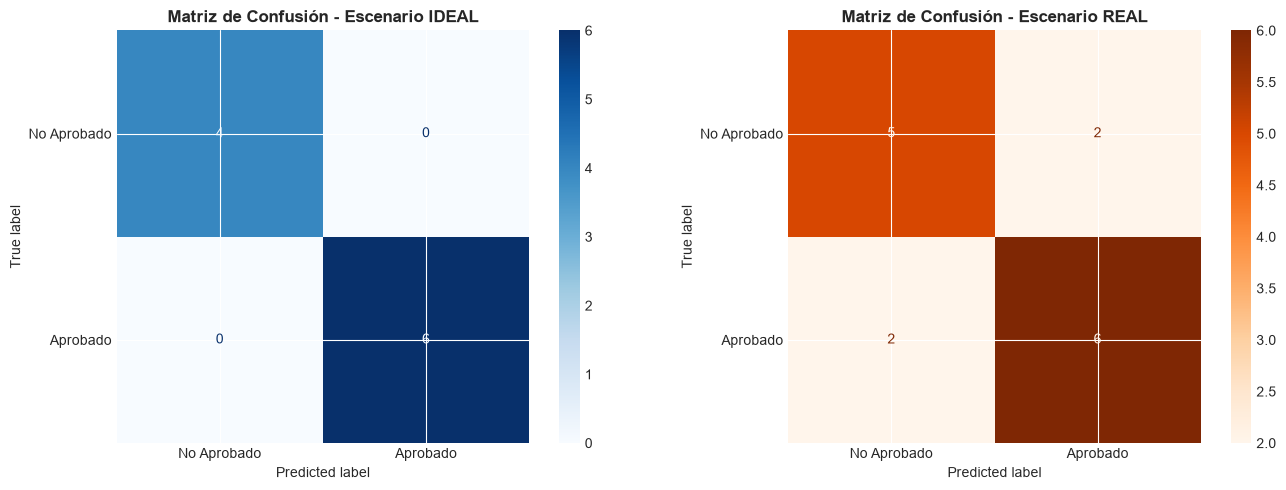

Matriz de Confusión - IDEAL:
[[4 0]
 [0 6]]

Matriz de Confusión - REAL:
[[5 2]
 [2 6]]


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión - Escenario Ideal
cm_ideal = confusion_matrix(resultado_examen_ideal, predicciones_ideal)
disp_ideal = ConfusionMatrixDisplay(confusion_matrix=cm_ideal, display_labels=['No Aprobado', 'Aprobado'])
disp_ideal.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusión - Escenario IDEAL', fontsize=12, fontweight='bold')

# Matriz de Confusión - Escenario Real
cm_real = confusion_matrix(resultado_examen_real, predicciones_real)
disp_real = ConfusionMatrixDisplay(confusion_matrix=cm_real, display_labels=['No Aprobado', 'Aprobado'])
disp_real.plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('Matriz de Confusión - Escenario REAL', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Matriz de Confusión - IDEAL:")
print(cm_ideal)
print("\nMatriz de Confusión - REAL:")
print(cm_real)

### Reporte de Clasificación Completo

In [13]:
print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN - ESCENARIO IDEAL")
print("="*70)
print(classification_report(resultado_examen_ideal, predicciones_ideal, 
                          target_names=['No Aprobado', 'Aprobado']))

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN - ESCENARIO REAL")
print("="*70)
print(classification_report(resultado_examen_real, predicciones_real, 
                          target_names=['No Aprobado', 'Aprobado']))


REPORTE DE CLASIFICACIÓN - ESCENARIO IDEAL
              precision    recall  f1-score   support

 No Aprobado       1.00      1.00      1.00         4
    Aprobado       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


REPORTE DE CLASIFICACIÓN - ESCENARIO REAL
              precision    recall  f1-score   support

 No Aprobado       0.71      0.71      0.71         7
    Aprobado       0.75      0.75      0.75         8

    accuracy                           0.73        15
   macro avg       0.73      0.73      0.73        15
weighted avg       0.73      0.73      0.73        15



### Curva ROC-AUC

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC - Ideal
fpr_ideal, tpr_ideal, _ = roc_curve(resultado_examen_ideal, probabilidades_originales_ideal)
roc_auc_ideal = auc(fpr_ideal, tpr_ideal)
axes[0].plot(fpr_ideal, tpr_ideal, color='blue', linewidth=3, 
            label=f'ROC Curve (AUC = {roc_auc_ideal:.2f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[0].set_title('Curva ROC - Escenario IDEAL', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ROC - Real
fpr_real, tpr_real, _ = roc_curve(resultado_examen_real, probabilidades_originales_real)
roc_auc_real = auc(fpr_real, tpr_real)
axes[1].plot(fpr_real, tpr_real, color='orange', linewidth=3, 
            label=f'ROC Curve (AUC = {roc_auc_real:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[1].set_title('Curva ROC - Escenario REAL', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Score - Escenario Ideal: {roc_auc_ideal:.4f}")
print(f"AUC Score - Escenario Real: {roc_auc_real:.4f}")

---

## Resumen y Conclusiones

In [ ]:
print("\n" + "#"*70)
print("#" + " "*68 + "#")
print("#" + "  RESUMEN DE APRENDIZAJES  ".center(68) + "#")
print("#" + " "*68 + "#")
print("#"*70)

print("\n1️⃣  FUNCIÓN SIGMOIDE:")
print("   - Convierte números en probabilidades (0 a 1)")
print("   - Tiene forma de 'S'")
print("   - Perfecta para problemas de clasificación")

print("\n2️⃣  ESCENARIOS COMPARADOS:")
print(f"   IDEAL (sin variabilidad):")
print(f"      - Accuracy: 100%")
print(f"      - Curva muy pronunciada")
print(f"      - División clara entre clases")
print(f"\n   REAL (con variabilidad):")
print(f"      - Accuracy: {accuracy_score(resultado_examen_real, predicciones_real):.0%}")
print(f"      - Curva menos pronunciada")
print(f"      - Excepciones y casos inesperados")

print("\n3️⃣  COEFICIENTES:")
print(f"   Ideal:")
print(f"      - β₀ (Intercepto): {modelo_ideal.intercept_[0]:.4f}")
print(f"      - β₁ (Coeficiente): {modelo_ideal.coef_[0][0]:.4f}")
print(f"\n   Real:")
print(f"      - β₀ (Intercepto): {modelo_real.intercept_[0]:.4f}")
print(f"      - β₁ (Coeficiente): {modelo_real.coef_[0][0]:.4f}")

print("\n4️⃣  INTERPRETACIÓN:")
print("   - Más horas de estudio = Mayor probabilidad de aprobar")
print("   - Pero no es garantía (especialmente en escenario real)")
print("   - Otros factores influyen (dificultad, salud, técnica, etc.)")

print("\n5️⃣  APLICACIONES PRÁCTICAS:")
print("   - Marketing: ¿Comprará este cliente?")
print("   - Medicina: ¿Tiene esta enfermedad?")
print("   - Finanzas: ¿Pagará el préstamo?")
print("   - Tecnología: ¿Es este email spam?")

print("\n" + "#"*70 + "\n")

## Conclusión Final

La **Regresión Logística** es un algoritmo fundamental en Machine Learning que:

✅ Es simple de entender e implementar
✅ Es rápido y eficiente
✅ Proporciona probabilidades interpretables
✅ Funciona bien incluso con datos limitados

Sin embargo:
⚠️ Asume relaciones lineales
⚠️ Es sensible a datos desbalanceados
⚠️ No maneja bien las relaciones complejas

**Próximos Pasos:**
- Explorar otros algoritmos (SVM, Random Forest, Redes Neuronales)
- Trabajar con datos reales y más complejos
- Aprender técnicas avanzadas de evaluación y validación cruzada